# RNN/LSTM Evaluation — Flickr8k

Covers:
- **a.** BLEU-4 + METEOR for all 12 variants (RNN & LSTM)
- **b.** Keras vs Scratch comparison (score + wall-clock time)
- **c.** RNN vs LSTM — qualitative analysis, 10 sample images
- **d.** Max caption length experiment (≥3 lengths)

**Run from repo root.**

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import json, time
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from src.captioning.preprocessing import load_vocab, load_split_ids, load_captions, clean_caption
from src.rnn.model import CaptioningModelScratch

## 1 — Load data & vocab

In [9]:
FEATURES_FILE = Path('../data/features/flickr8k_features.npy')
VOCAB_FILE    = Path('../data/flickr8k/vocab.json')
CAPTIONS_FILE = Path('../data/flickr8k/captions.txt')
IMAGE_DIR     = Path('../data/flickr8k/Images')
MODEL_DIR     = Path('../models/rnn')
MAX_LEN       = 35

features  = np.load(FEATURES_FILE, allow_pickle=True).item()
word2idx, idx2word = load_vocab(VOCAB_FILE)
captions  = load_captions(CAPTIONS_FILE)
_, _, test_ids = load_split_ids('../data/flickr8k')

VOCAB_SIZE = len(word2idx)
print(f'Test images: {len(test_ids)} | Vocab: {VOCAB_SIZE}')

Test images: 1092 | Vocab: 7449


## 2 — Evaluation helpers

In [10]:
def get_references(test_ids, captions):
    """Build BLEU-4 reference list: [[ref1_tokens, ref2_tokens, ...], ...]"""
    refs = []
    for fname in test_ids:
        img_refs = [clean_caption(c).split() for c in captions.get(fname, [])]
        refs.append(img_refs)
    return refs


def compute_bleu4(references, hypotheses):
    """Corpus BLEU-4 with smoothing."""
    smooth = SmoothingFunction().method1
    return corpus_bleu(references, [h.split() for h in hypotheses],
                       smoothing_function=smooth)


def compute_meteor(references, hypotheses):
    """Average METEOR over test set."""
    scores = []
    for refs, hyp in zip(references, hypotheses):
        score = max(meteor_score([r for r in refs], hyp.split()) for r in refs)
        scores.append(score)
    return np.mean(scores)


def keras_greedy_decode(model, img_feat, word2idx, idx2word, max_len=25):
    """Greedy decode using the Keras model directly."""
    seq_len = max_len - 1
    feat    = img_feat.reshape(1, -1).astype(np.float32)
    token   = word2idx['<start>']
    caption = []

    for _ in range(max_len):
        cap_in  = np.zeros((1, seq_len), dtype=np.int32)
        cap_in[0, :len(caption)+1] = [word2idx['<start>']] + \
                                      [word2idx.get(w, word2idx['<unk>']) for w in caption]
        preds   = model.predict({'img_feat': feat, 'caption_in': cap_in}, verbose=0)
        next_id = int(np.argmax(preds[0, len(caption)]))
        word    = idx2word.get(next_id, '<unk>')
        if word in ('<end>', '<pad>'):
            break
        caption.append(word)

    return ' '.join(caption)


refs_test = get_references(test_ids, captions)
print('References built.')

References built.


## 3a — BLEU-4 & METEOR for all 12 variants (Scratch)

In [11]:
CONFIGS = [
    ('rnn',  1, 128), ('rnn',  1, 512),
    ('rnn',  2, 128), ('rnn',  2, 512),
    ('rnn',  3, 128), ('rnn',  3, 512),
    ('lstm', 1, 128), ('lstm', 1, 512),
    ('lstm', 2, 128), ('lstm', 2, 512),
    ('lstm', 3, 128), ('lstm', 3, 512),
]

results = {}   # cfg_name → {bleu4, meteor, time_per_img}

for dec_type, n_layers, n_hidden in CONFIGS:
    cfg_name  = f'{dec_type}_L{n_layers}_H{n_hidden}'
    model_path = MODEL_DIR / f'{cfg_name}.keras'
    if not model_path.exists():
        print(f'[SKIP] {cfg_name} — model not found')
        continue

    print(f'Evaluating (scratch): {cfg_name} ...')
    keras_model = keras.models.load_model(str(model_path))
    scratch     = CaptioningModelScratch(keras_model, word2idx, idx2word,
                                         decoder_type=dec_type,
                                         num_rnn_layers=n_layers)

    t0   = time.time()
    hyps = [scratch.generate_caption(features[fname], max_len=25)
            for fname in test_ids]
    elapsed = time.time() - t0

    bleu4  = compute_bleu4(refs_test, hyps)
    meteor = compute_meteor(refs_test, hyps)

    results[cfg_name] = {
        'bleu4':        bleu4,
        'meteor':       meteor,
        'time_per_img': elapsed / len(test_ids),
        'hypotheses':   hyps,
    }
    print(f'  BLEU-4={bleu4:.4f}  METEOR={meteor:.4f}  '
          f'time/img={elapsed/len(test_ids)*1000:.1f}ms')

# Save scores (without hypotheses to keep file small)
scores_to_save = {k: {m: v for m, v in d.items() if m != 'hypotheses'}
                  for k, d in results.items()}
with open(MODEL_DIR / 'eval_scratch_scores.json', 'w') as f:
    json.dump(scores_to_save, f, indent=2)

Evaluating (scratch): rnn_L1_H128 ...
  BLEU-4=0.0973  METEOR=0.2896  time/img=5.6ms
Evaluating (scratch): rnn_L1_H512 ...
  BLEU-4=0.1144  METEOR=0.3245  time/img=9.5ms
Evaluating (scratch): rnn_L2_H128 ...
  BLEU-4=0.0911  METEOR=0.2911  time/img=5.8ms
Evaluating (scratch): rnn_L2_H512 ...
  BLEU-4=0.1256  METEOR=0.3130  time/img=10.5ms
Evaluating (scratch): rnn_L3_H128 ...
  BLEU-4=0.1240  METEOR=0.3101  time/img=5.7ms
Evaluating (scratch): rnn_L3_H512 ...
  BLEU-4=0.0002  METEOR=0.0982  time/img=15.4ms
Evaluating (scratch): lstm_L1_H128 ...
  BLEU-4=0.0003  METEOR=0.1071  time/img=6.5ms
Evaluating (scratch): lstm_L1_H512 ...
  BLEU-4=0.0002  METEOR=0.1064  time/img=15.1ms
Evaluating (scratch): lstm_L2_H128 ...
  BLEU-4=0.0001  METEOR=0.1039  time/img=7.5ms
Evaluating (scratch): lstm_L2_H512 ...
  BLEU-4=0.0003  METEOR=0.1030  time/img=24.4ms
Evaluating (scratch): lstm_L3_H128 ...
  BLEU-4=0.0004  METEOR=0.1072  time/img=10.6ms
Evaluating (scratch): lstm_L3_H512 ...
  BLEU-4=0.0004 

In [12]:
# Table: BLEU-4 and METEOR for all variants
print(f"{'Config':<22} {'BLEU-4':>8} {'METEOR':>8} {'ms/img':>8}")
print('-' * 50)
for cfg, r in sorted(results.items(), key=lambda x: -x[1]['bleu4']):
    print(f"{cfg:<22} {r['bleu4']:>8.4f} {r['meteor']:>8.4f} {r['time_per_img']*1000:>7.1f}")

Config                   BLEU-4   METEOR   ms/img
--------------------------------------------------
rnn_L2_H512              0.1256   0.3130    10.5
rnn_L3_H128              0.1240   0.3101     5.7
rnn_L1_H512              0.1144   0.3245     9.5
rnn_L1_H128              0.0973   0.2896     5.6
rnn_L2_H128              0.0911   0.2911     5.8
lstm_L3_H128             0.0004   0.1072    10.6
lstm_L3_H512             0.0004   0.1049    29.6
lstm_L1_H128             0.0003   0.1071     6.5
lstm_L2_H512             0.0003   0.1030    24.4
lstm_L1_H512             0.0002   0.1064    15.1
rnn_L3_H512              0.0002   0.0982    15.4
lstm_L2_H128             0.0001   0.1039     7.5


## 3b — Keras vs Scratch (best RNN & best LSTM)

In [13]:
def best_config(results, decoder_type):
    filtered = {k: v for k, v in results.items() if k.startswith(decoder_type)}
    return max(filtered, key=lambda k: filtered[k]['bleu4'])

best_rnn_cfg  = best_config(results, 'rnn')
best_lstm_cfg = best_config(results, 'lstm')
print(f'Best RNN : {best_rnn_cfg}  BLEU-4={results[best_rnn_cfg]["bleu4"]:.4f}')
print(f'Best LSTM: {best_lstm_cfg}  BLEU-4={results[best_lstm_cfg]["bleu4"]:.4f}')

Best RNN : rnn_L2_H512  BLEU-4=0.1256
Best LSTM: lstm_L3_H128  BLEU-4=0.0004


In [15]:
keras_results = {}

for cfg_name in [best_rnn_cfg, best_lstm_cfg]:
    dec_type = cfg_name.split('_')[0]
    model_path = MODEL_DIR / f'{cfg_name}.keras'
    print(f'Evaluating (Keras): {cfg_name} ...')

    keras_model = keras.models.load_model(str(model_path))

    t0   = time.time()
    hyps = [keras_greedy_decode(keras_model, features[fname], word2idx, idx2word, max_len=35)
            for fname in test_ids]
    elapsed = time.time() - t0

    bleu4  = compute_bleu4(refs_test, hyps)
    meteor = compute_meteor(refs_test, hyps)

    keras_results[cfg_name] = {
        'bleu4':        bleu4,
        'meteor':       meteor,
        'time_per_img': elapsed / len(test_ids),
    }
    print(f'  BLEU-4={bleu4:.4f}  METEOR={meteor:.4f}  '
          f'time/img={elapsed/len(test_ids)*1000:.1f}ms')

Evaluating (Keras): rnn_L2_H512 ...
  BLEU-4=0.1256  METEOR=0.3130  time/img=1791.7ms
Evaluating (Keras): lstm_L3_H128 ...
  BLEU-4=0.0004  METEOR=0.1072  time/img=2006.9ms


In [16]:
print('\nKeras vs Scratch comparison:')
print(f"{'Config':<22} {'Impl':>8} {'BLEU-4':>8} {'METEOR':>8} {'ms/img':>8}")
print('-' * 58)
for cfg in [best_rnn_cfg, best_lstm_cfg]:
    s = results[cfg]
    k = keras_results[cfg]
    print(f"{cfg:<22} {'scratch':>8} {s['bleu4']:>8.4f} {s['meteor']:>8.4f} {s['time_per_img']*1000:>7.1f}")
    print(f"{'':<22} {'keras':>8} {k['bleu4']:>8.4f} {k['meteor']:>8.4f} {k['time_per_img']*1000:>7.1f}")
    print()


Keras vs Scratch comparison:
Config                     Impl   BLEU-4   METEOR   ms/img
----------------------------------------------------------
rnn_L2_H512             scratch   0.1256   0.3130    10.5
                          keras   0.1256   0.3130  1791.7

lstm_L3_H128            scratch   0.0004   0.1072    10.6
                          keras   0.0004   0.1072  2006.9



## 3c — RNN vs LSTM: Qualitative Analysis

In [17]:
# Per-image BLEU-4 for best RNN and best LSTM scratch models
smooth = SmoothingFunction().method1

def per_image_bleu4(hyps, references):
    scores = []
    for ref, hyp in zip(references, hyps):
        s = corpus_bleu([ref], [hyp.split()], smoothing_function=smooth)
        scores.append(s)
    return np.array(scores)

rnn_hyps  = results[best_rnn_cfg]['hypotheses']
lstm_hyps = results[best_lstm_cfg]['hypotheses']

rnn_scores  = per_image_bleu4(rnn_hyps,  refs_test)
lstm_scores = per_image_bleu4(lstm_hyps, refs_test)
avg_scores  = (rnn_scores + lstm_scores) / 2

# Select 10 images: 3 high, 4 mid, 3 low BLEU-4
sorted_idx = np.argsort(avg_scores)
low_idx    = sorted_idx[:3].tolist()
mid_idx    = sorted_idx[len(sorted_idx)//2 - 2 : len(sorted_idx)//2 + 2].tolist()
high_idx   = sorted_idx[-3:].tolist()
selected   = low_idx + mid_idx + high_idx

print('Selected image indices (low / mid / high BLEU-4):', selected)

Selected image indices (low / mid / high BLEU-4): [1020, 735, 501, 109, 1015, 830, 265, 965, 415, 1044]


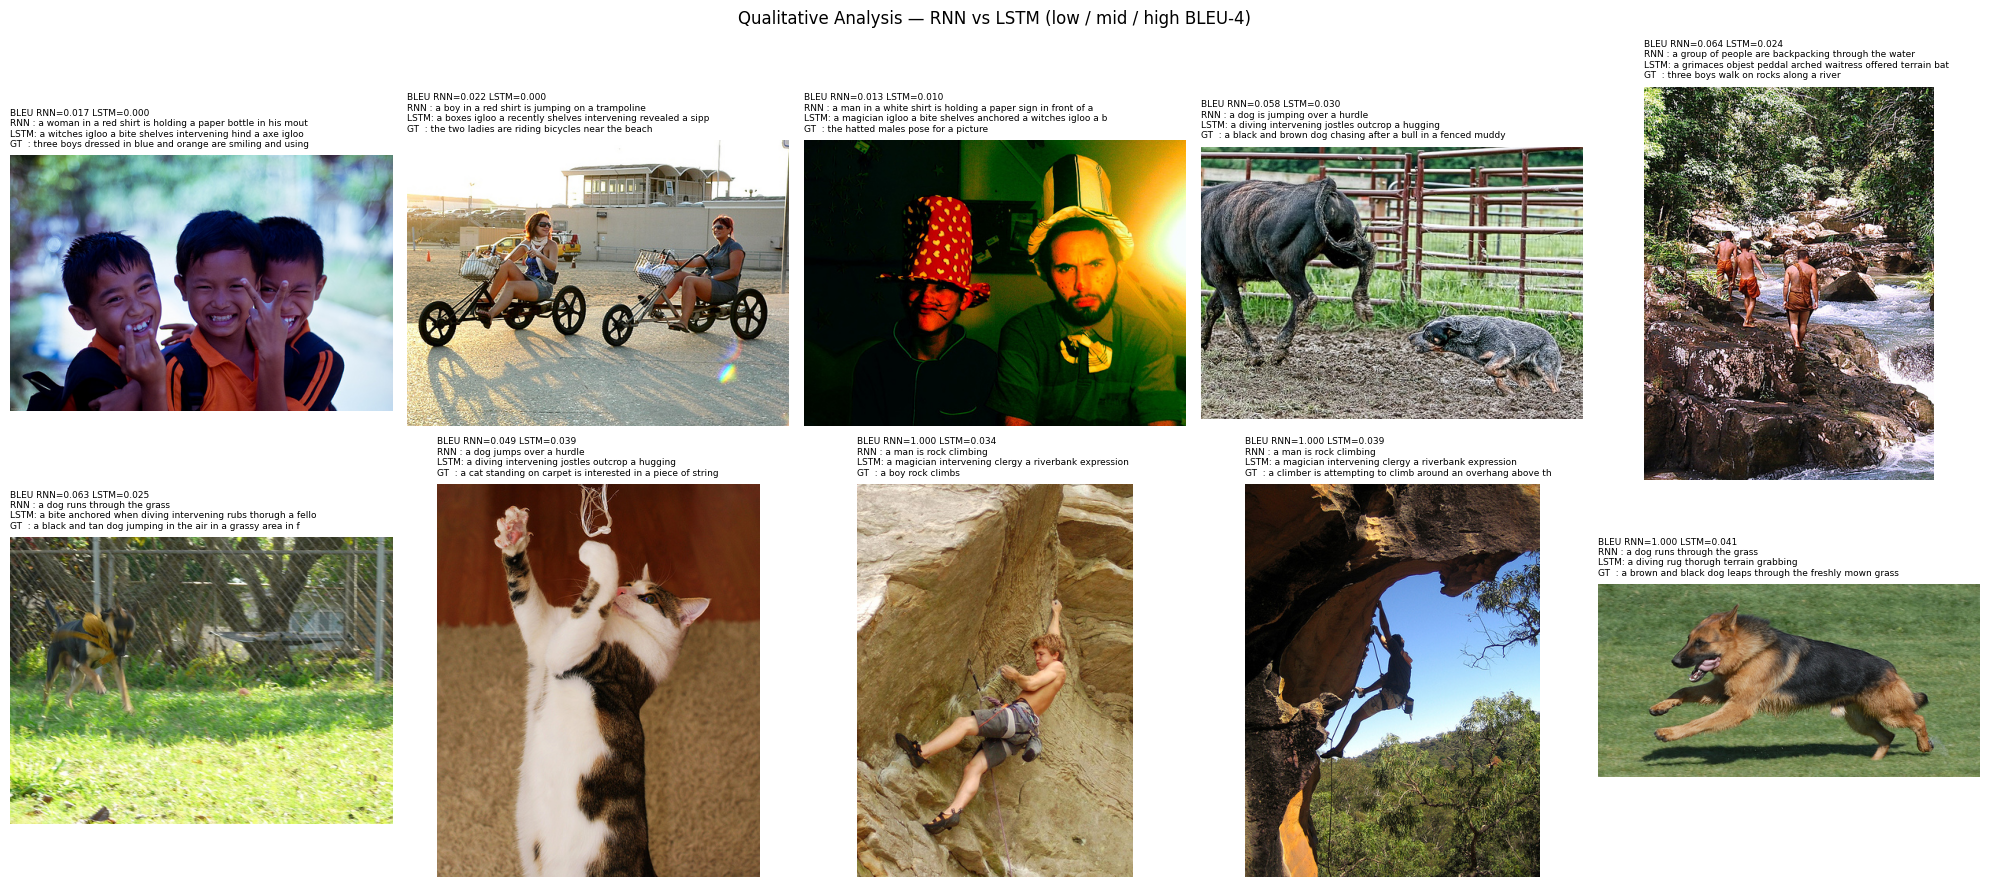

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

for ax, idx in zip(axes, selected):
    fname   = test_ids[idx]
    img_path = IMAGE_DIR / fname

    if img_path.exists():
        img = mpimg.imread(str(img_path))
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, 'image not found', ha='center', va='center', transform=ax.transAxes)

    rnn_cap  = rnn_hyps[idx]
    lstm_cap = lstm_hyps[idx]
    gt_cap   = clean_caption(captions[fname][0])

    title = (f"BLEU RNN={rnn_scores[idx]:.3f} LSTM={lstm_scores[idx]:.3f}\n"
             f"RNN : {rnn_cap[:60]}\n"
             f"LSTM: {lstm_cap[:60]}\n"
             f"GT  : {gt_cap[:60]}")
    ax.set_title(title, fontsize=6.5, loc='left')
    ax.axis('off')

plt.suptitle('Qualitative Analysis — RNN vs LSTM (low / mid / high BLEU-4)', fontsize=12)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'qualitative_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## 3d — Max Caption Length Experiment

In [19]:
# Pick overall best model (highest BLEU-4 across all 4 candidates)
all_candidates = {
    best_rnn_cfg:  results[best_rnn_cfg]['bleu4'],
    best_lstm_cfg: results[best_lstm_cfg]['bleu4'],
}
overall_best_cfg = max(all_candidates, key=all_candidates.get)
overall_best_dec = overall_best_cfg.split('_')[0]
overall_best_layers = int(overall_best_cfg.split('_L')[1].split('_')[0])
print(f'Overall best: {overall_best_cfg}')

best_keras = keras.models.load_model(str(MODEL_DIR / f'{overall_best_cfg}.keras'))
best_scratch = CaptioningModelScratch(best_keras, word2idx, idx2word,
                                       decoder_type=overall_best_dec,
                                       num_rnn_layers=overall_best_layers)

Overall best: rnn_L2_H512


In [20]:
MAX_LEN_VARIANTS = [15, 25, 40]
len_results = {}

for ml in MAX_LEN_VARIANTS:
    hyps   = [best_scratch.generate_caption(features[fname], max_len=ml) for fname in test_ids]
    bleu4  = compute_bleu4(refs_test, hyps)
    meteor = compute_meteor(refs_test, hyps)
    avg_len = np.mean([len(h.split()) for h in hyps])
    len_results[ml] = {'bleu4': bleu4, 'meteor': meteor, 'avg_caption_len': avg_len}
    print(f'max_len={ml:3d}  BLEU-4={bleu4:.4f}  METEOR={meteor:.4f}  avg_len={avg_len:.1f}')

max_len= 15  BLEU-4=0.1259  METEOR=0.3132  avg_len=9.7
max_len= 25  BLEU-4=0.1256  METEOR=0.3130  avg_len=9.7
max_len= 40  BLEU-4=0.1256  METEOR=0.3130  avg_len=9.7


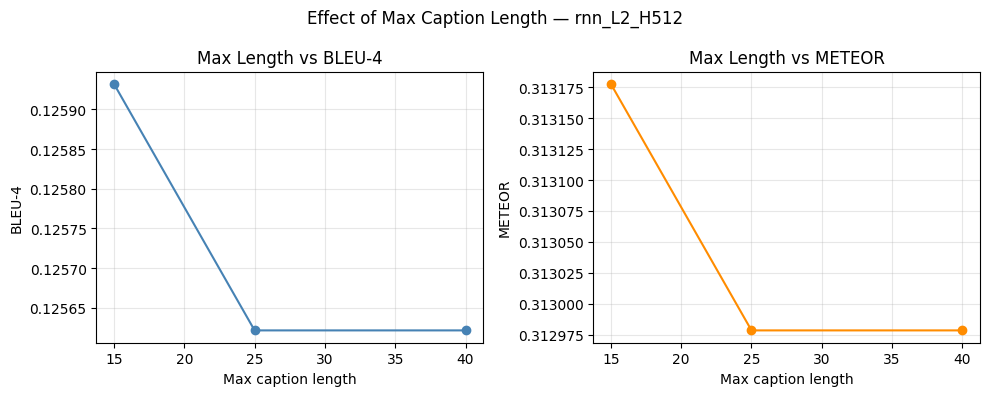

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
mls    = list(len_results.keys())
bleus  = [len_results[m]['bleu4']  for m in mls]
meteors= [len_results[m]['meteor'] for m in mls]

ax1.plot(mls, bleus,   'o-', color='steelblue')
ax1.set_xlabel('Max caption length'); ax1.set_ylabel('BLEU-4')
ax1.set_title('Max Length vs BLEU-4'); ax1.grid(True, alpha=0.3)

ax2.plot(mls, meteors, 'o-', color='darkorange')
ax2.set_xlabel('Max caption length'); ax2.set_ylabel('METEOR')
ax2.set_title('Max Length vs METEOR'); ax2.grid(True, alpha=0.3)

plt.suptitle(f'Effect of Max Caption Length — {overall_best_cfg}')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'max_len_experiment.png', dpi=120)
plt.show()